<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 256
x = np.linspace(0, 2*np.pi, N, endpoint=False)
A = 0.1
sigma = 0.2
centers = [np.pi/4, np.pi, 7*np.pi/4]

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

phi = sum(gaussian(c, sigma, A) for c in centers)
history = [phi.copy()]


In [2]:
dt = 0.02
gamma = 0.005
lam = 0.5

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def evolve(phi):
    return phi + dt * (laplacian(phi) - gamma * phi + lam * phi**3)

for t in range(300):
    phi = evolve(phi)
    if t % 50 == 0:
        history.append(phi.copy())


In [3]:
def correlation(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return (np.dot(a, b) / denom) if denom > 0 else 0.0

def node_correlation(phi, centers, sigma):
    nodes = [gaussian(c, sigma, 1.0) for c in centers]
    return [correlation(phi, n) for n in nodes]

node_corrs = [node_correlation(h, centers, sigma) for h in history]


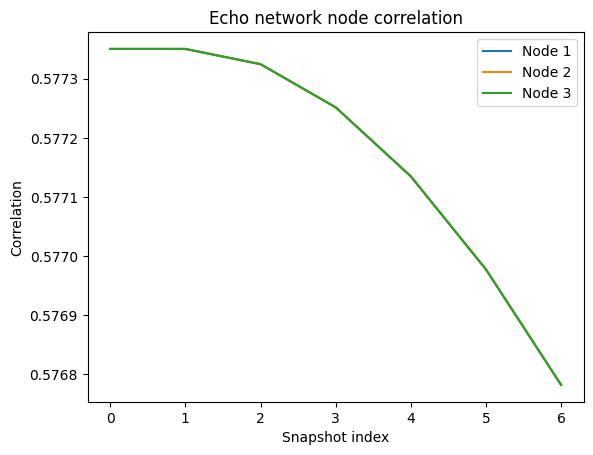

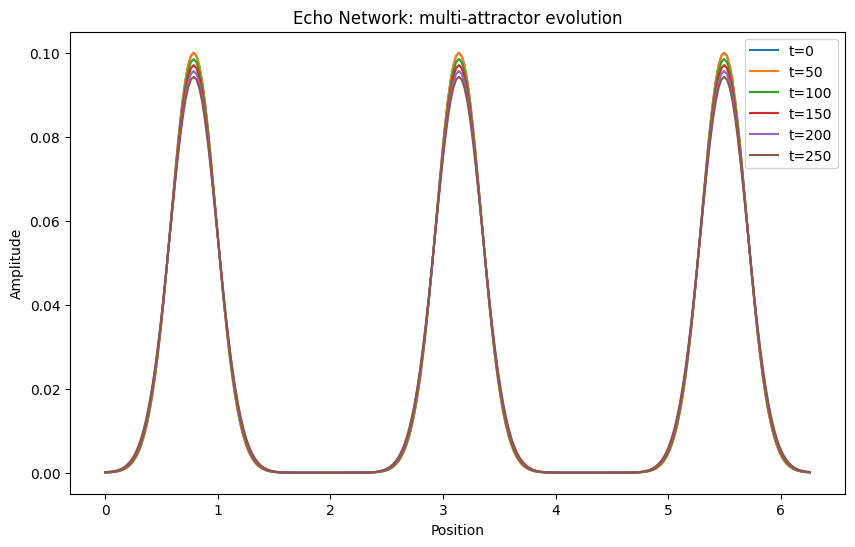

In [4]:
# Node correlation over time
node_corrs = np.array(node_corrs)
for i in range(len(centers)):
    plt.plot(node_corrs[:, i], label=f"Node {i+1}")
plt.xlabel("Snapshot index")
plt.ylabel("Correlation")
plt.title("Echo network node correlation")
plt.legend()
plt.show()

# Snapshots
plt.figure(figsize=(10,6))
for i, h in enumerate(history[:6]):
    plt.plot(x, h, label=f"t={i*50}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Echo Network: multi-attractor evolution")
plt.legend()
plt.show()
